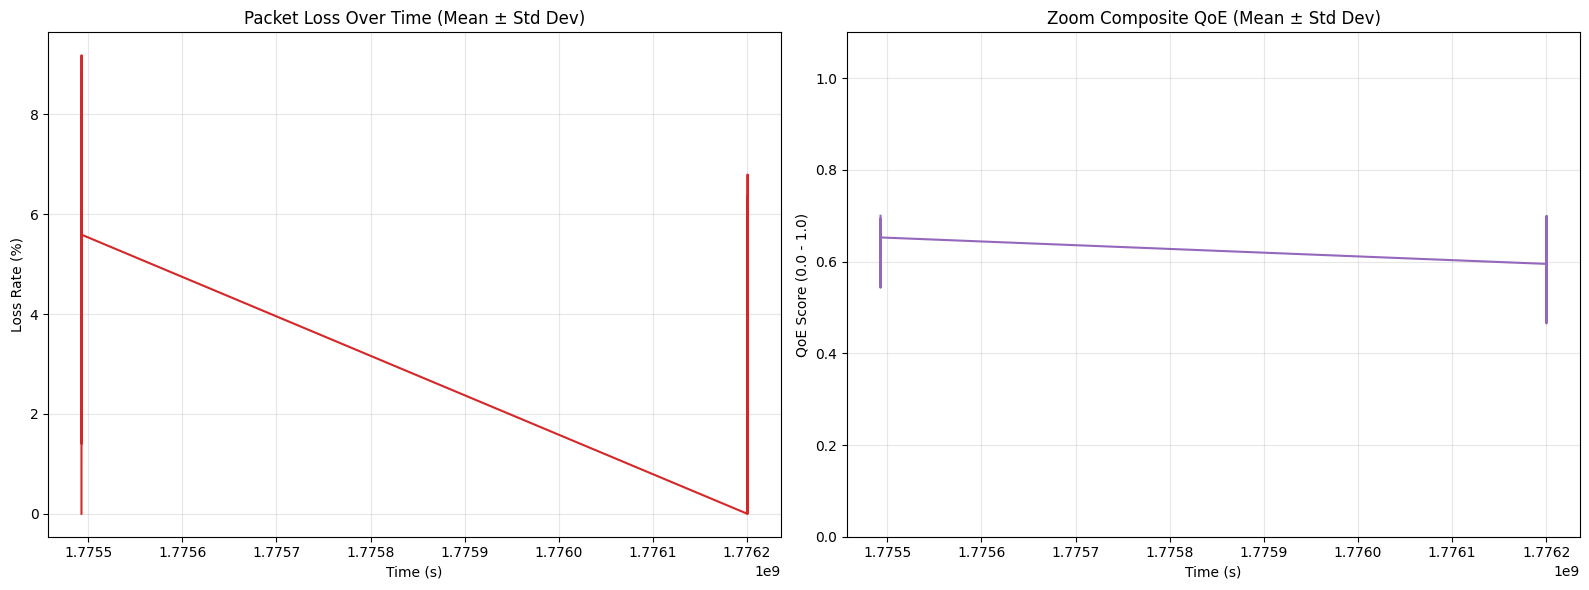

AGGREGATED PERFORMANCE (Across 3 Trials)
Mean QoE Score: 0.654 ± 0.008
Mean Loss Rate: 3.67%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. SETUP PATHS AND TRIALS
# List your trial subdirectories here
trial_dirs = ['trial_1', 'trial_3'] 
all_trials_qoe = []
all_trials_loss = []

def process_dataframe(filepath):
    """Processes a single stats.csv and returns calculated metrics."""
    df = pd.read_csv(filepath)
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Metric Calculation
    df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
    df["loss_rate"] = df["loss_rate"].clip(0, 1)

    if 'bytes' in df.columns:
        df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6
    if 'mean_jitter' in df.columns:
        df['jitter_ms'] = df['mean_jitter'] * 1000

    # Normalization & QoE
    w1, w2, w3 = 0.4, 0.3, 0.3
    df['fps_norm'] = (df['frames'] / 30).clip(0, 1)
    df['jitter_norm'] = (1 - (df['jitter_ms'] / 40)).clip(0, 1)
    df['qoe_score'] = (w1 * (1 - df['loss_rate'])) + (w2 * df['fps_norm']) + (w3 * df['jitter_norm'])
    
    return df

# 2. LOAD AND AGGREGATE DATA
for trial in trial_dirs:
    path = os.path.join(trial, "stats.csv")
    if os.path.exists(path):
        temp_df = process_dataframe(path)
        
        # Group by second to ensure timestamps align across trials
        qoe_ts = temp_df.groupby("ts_s")["qoe_score"].mean()
        loss_ts = temp_df.groupby("ts_s")["loss_rate"].mean()
        
        all_trials_qoe.append(qoe_ts)
        all_trials_loss.append(loss_ts)

# Create Master DataFrames (Rows = Time, Columns = Trial Number)
qoe_master = pd.concat(all_trials_qoe, axis=1)
loss_master = pd.concat(all_trials_loss, axis=1)

# Calculate Mean and Standard Deviation across trials
qoe_avg = qoe_master.mean(axis=1)
qoe_err = qoe_master.std(axis=1)

loss_avg = loss_master.mean(axis=1)
loss_err = loss_master.std(axis=1)

# 3. PLOTS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss Rate with Error Shading
axes[0].plot(loss_avg.index, loss_avg * 100, color='#d62728', label='Mean Loss')
axes[0].fill_between(loss_avg.index, (loss_avg - loss_err)*100, (loss_avg + loss_err)*100, color='#d62728', alpha=0.2)
axes[0].set_ylabel('Loss Rate (%)')
axes[0].set_xlabel('Time (s)')
axes[0].set_title('Packet Loss Over Time (Mean ± Std Dev)')
axes[0].grid(True, alpha=0.3)

# Plot 2: QoE Score with Error Shading
axes[1].plot(qoe_avg.index, qoe_avg, color='#9467bd', label='Mean QoE')
axes[1].fill_between(qoe_avg.index, qoe_avg - qoe_err, qoe_avg + qoe_err, color='#9467bd', alpha=0.2)
axes[1].set_ylabel('QoE Score (0.0 - 1.0)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Zoom Composite QoE (Mean ± Std Dev)')
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_trial_analysis.png', dpi=150)
plt.show()

# 4. SUMMARY STATISTICS
print("=" * 50)
print("AGGREGATED PERFORMANCE (Across 3 Trials)")
print("=" * 50)
print(f"Mean QoE Score: {qoe_avg.mean():.3f} ± {qoe_master.mean().std():.3f}")
print(f"Mean Loss Rate: {loss_avg.mean()*100:.2f}%")
print("=" * 50)